In [45]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import ta
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [46]:
# 1. Fetch Nifty 100 Data
ticker = "^CNX100"
try:
    print(f"Fetching data for {ticker}...")
    df = yf.download(ticker, start="2010-01-01")
    
    if df.empty:
        print("Data is empty. Trying fallback ticker ^NSEI (Nifty 50).")
        ticker = "^NSEI"
        df = yf.download(ticker, start="2010-01-01")
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    print(f"Data fetched successfully. Rows: {len(df)}")
    print(df.head())
except Exception as e:
    print(f"Error fetching data: {e}")

Fetching data for ^CNX100...


[*********************100%***********************]  1 of 1 completed

Data fetched successfully. Rows: 3994
Price             Close         High          Low         Open   Volume
Date                                                                   
2010-01-04  5153.549805  5158.049805  5098.500000  5098.500000  2432500
2010-01-05  5203.799805  5211.350098  5182.100098  5188.549805  3755200
2010-01-06  5214.000000  5228.250000  5191.100098  5221.649902  3292300
2010-01-07  5191.700195  5229.500000  5175.950195  5213.450195  2849900
2010-01-08  5175.750000  5206.500000  5165.850098  5193.450195  3145000


In [47]:
# 2. Feature Engineering
# Calculating technical indicators
df['SMA_10'] = ta.trend.sma_indicator(df['Close'], window=10)
df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)
df['EMA_10'] = ta.trend.ema_indicator(df['Close'], window=10)
df['EMA_50'] = ta.trend.ema_indicator(df['Close'], window=50)
df['RSI'] = ta.momentum.rsi(df['Close'], window=14)
df['MACD'] = ta.trend.macd_diff(df['Close'])
df['BB_High'] = ta.volatility.bollinger_hband(df['Close'])
df['BB_Low'] = ta.volatility.bollinger_lband(df['Close'])
df['ATR'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'])

df.dropna(inplace=True)

# Define Target: 1 if Close (t) > Close (t-1), else 0
df['Target'] = np.where(df['Close'] > df['Close'].shift(1), 1, 0)

# Select features
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 
                'SMA_10', 'SMA_50', 'EMA_10', 'EMA_50', 
                'RSI', 'MACD', 'BB_High', 'BB_Low', 'ATR']

# We drop the first row because of shift in target, but actually for LSTM we use sequences.
# Let's align features and target. We want to predict Target[t] using features up to t-1.
# So X should be shifted by 1 relative to Target.
X = df[feature_cols].shift(1).iloc[1:]
y = df['Target'].iloc[1:]
data = X
data['Target'] = y  # Temporarily putting them together for sequencing

# Check data
print(data.head())

Price              Open         High          Low        Close     Volume  \
Date                                                                        
2010-03-18  5147.299805  5185.750000  5146.850098  5155.899902  2406200.0   
2010-03-19  5163.399902  5177.799805  5140.350098  5168.950195  2296200.0   
2010-03-22  5181.149902  5191.600098  5163.000000  5186.549805  1955300.0   
2010-03-23  5161.100098  5175.899902  5118.950195  5131.399902  1985700.0   
2010-03-25  5144.700195  5168.649902  5122.399902  5151.000000  2132200.0   

Price            SMA_10       SMA_50       EMA_10       EMA_50        RSI  \
Date                                                                        
2010-03-18  5076.320020  4971.690000  5064.384157  4990.112197  70.103591   
2010-03-19  5089.715039  4971.998008  5083.396164  4997.125452  71.009602   
2010-03-22  5103.710010  4971.653008  5102.151371  5004.553858  72.231769   
2010-03-23  5108.970020  4970.001006  5107.469286  5009.528213  63.235480  

In [48]:
# 3. Data Preparation for CNN-LSTM
from sklearn.preprocessing import StandardScaler

sequence_length = 60  # Number of past days to look at
features = feature_cols
target = 'Target'

# Split into Train/Test first to avoid data leakage
# We use 80% for training
split_idx = int(0.8 * len(data))
train_df = data.iloc[:split_idx]
test_df = data.iloc[split_idx:]

# Scaling - Use StandardScaler for better handling of outliers
scaler = StandardScaler()
scaler.fit(train_df[features])

# Transform both
# train_scaled = scaler.transform(train_df[features]) # Not used directly
data_scaled_full = scaler.transform(data[features]) 
target_values = data[target].values

X_seq, y_seq = [], []

for i in range(sequence_length - 1, len(data)):
    X_seq.append(data_scaled_full[i - sequence_length + 1 : i + 1])
    y_seq.append(target_values[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

train_len = split_idx - (sequence_length - 1)

X_train = X_seq[:train_len]
y_train = y_seq[:train_len]
X_test = X_seq[train_len:]
y_test = y_seq[train_len:]

# Calculate Class Weights
num_pos = np.sum(y_train)
num_neg = len(y_train) - num_pos
pos_weight = num_neg / num_pos
print(f"Positive samples: {num_pos}, Negative samples: {num_neg}")
print(f"Calculated pos_weight: {pos_weight:.4f}")

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Define Dataset and DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train_tensor, y_train_tensor)
test_dataset = TimeSeriesDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Positive samples: 1668, Negative samples: 1428
Calculated pos_weight: 0.8561
Train shape: (3096, 60, 14), Test shape: (789, 60, 14)


In [49]:
# 4. Build CNN-LSTM Model
class CNNLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout_prob=0.3):
        super(CNNLSTM, self).__init__()
        
        # CNN Layers
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout1 = nn.Dropout(dropout_prob)
        
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.dropout2 = nn.Dropout(dropout_prob)
        
        # LSTM Layers
        self.lstm = nn.LSTM(input_size=128, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout_prob)
        
        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(32, output_dim)
        )
        # Note: No Sigmoid here because we will use BCEWithLogitsLoss

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        x = x.permute(0, 2, 1) # (batch, features, seq_len)
        
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)
        
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout2(x)
        
        # Prepare for LSTM: (batch, seq_len, features)
        x = x.permute(0, 2, 1) # (batch, new_seq_len, 128)
        
        lstm_out, _ = self.lstm(x)
        # Take the output of the last time step
        last_out = lstm_out[:, -1, :]
        
        out = self.fc_layers(last_out)
        return out

# Model parameters
input_dim = len(features)
hidden_dim = 64
num_layers = 2
output_dim = 1
dropout_prob = 0.3

model = CNNLSTM(input_dim, hidden_dim, num_layers, output_dim, dropout_prob).to(device)
print(model)

CNNLSTM(
  (conv1): Conv1d(14, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.3, inplace=False)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (dropout2): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc_layers): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [50]:
# 5. Train Model
# Modified to balance recall/precision for both classes
# Using default BCEWithLogitsLoss (no pos_weight) but adding regularization and better optimization
torch.manual_seed(42)

criterion = nn.BCEWithLogitsLoss() # Let the model learn naturally
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5) # Lower LR and add L2 reg
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10) # Removed verbose=True

num_epochs = 100 
train_losses = []
val_accuracies = []
best_val_acc = 0.0

print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs_batch, labels_batch in train_loader:
        inputs_batch = inputs_batch.to(device)
        labels_batch = labels_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item()
        
        # Calculate training accuracy
        probs = torch.sigmoid(outputs)
        predicted = (probs > 0.5).float()
        total_train += labels_batch.size(0)
        correct_train += (predicted == labels_batch).sum().item()
    
    avg_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train
    train_losses.append(avg_loss)
    
    # Validation
    model.eval()
    val_loss_sum = 0
    correct = 0
    total = 0
    tp = 0
    tn = 0
    fp = 0
    fn = 0
    
    with torch.no_grad():
        for inputs_batch, labels_batch in test_loader:
            inputs_batch = inputs_batch.to(device)
            labels_batch = labels_batch.to(device)
            
            outputs = model(inputs_batch)
            loss = criterion(outputs, labels_batch)
            val_loss_sum += loss.item()
            
            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).float()
            
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()
            
            # Use strict comparison for confusion matrix elements
            current_tp = ((predicted == 1) & (labels_batch == 1)).sum().item()
            current_tn = ((predicted == 0) & (labels_batch == 0)).sum().item()
            current_fp = ((predicted == 1) & (labels_batch == 0)).sum().item()
            current_fn = ((predicted == 0) & (labels_batch == 1)).sum().item()
            
            tp += current_tp
            tn += current_tn
            fp += current_fp
            fn += current_fn
        
        val_acc = correct / total
        val_loss = val_loss_sum / len(test_loader)
        val_accuracies.append(val_acc)
        
        # Recall for 1 (Sensitivity) = TP / (TP + FN)
        recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        # Recall for 0 (Specificity) = TN / (TN + FP)
        recall_0 = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        
        scheduler.step(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}, R1: {recall_1:.2f}, R0: {recall_0:.2f}")

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Starting training...
Epoch [5/100], Loss: 0.6905, Val Acc: 0.5526, R1: 1.00, R0: 0.00
Epoch [10/100], Loss: 0.6893, Val Acc: 0.4575, R1: 0.10, R0: 0.90
Epoch [15/100], Loss: 0.6882, Val Acc: 0.4994, R1: 0.33, R0: 0.71
Epoch [20/100], Loss: 0.6857, Val Acc: 0.4943, R1: 0.22, R0: 0.84
Epoch [25/100], Loss: 0.6838, Val Acc: 0.4930, R1: 0.37, R0: 0.64
Epoch [30/100], Loss: 0.6835, Val Acc: 0.5006, R1: 0.39, R0: 0.64
Epoch [35/100], Loss: 0.6816, Val Acc: 0.5032, R1: 0.32, R0: 0.73
Epoch [40/100], Loss: 0.6811, Val Acc: 0.5006, R1: 0.53, R0: 0.47
Epoch [45/100], Loss: 0.6791, Val Acc: 0.5095, R1: 0.55, R0: 0.46
Epoch [50/100], Loss: 0.6789, Val Acc: 0.5171, R1: 0.51, R0: 0.53
Epoch [55/100], Loss: 0.6792, Val Acc: 0.5057, R1: 0.49, R0: 0.53
Epoch [60/100], Loss: 0.6776, Val Acc: 0.4994, R1: 0.51, R0: 0.49
Epoch [65/100], Loss: 0.6782, Val Acc: 0.4981, R1: 0.50, R0: 0.49
Epoch [70/100], Loss: 0.6794, Val Acc: 0.4981, R1: 0.52, R0: 0.47
Epoch [75/100], Loss: 0.6780, Val Acc: 0.4943, R1: 0.51,

Test Accuracy: 0.4956
              precision    recall  f1-score   support

         0.0       0.44      0.46      0.45       353
         1.0       0.55      0.52      0.53       436

    accuracy                           0.50       789
   macro avg       0.49      0.49      0.49       789
weighted avg       0.50      0.50      0.50       789



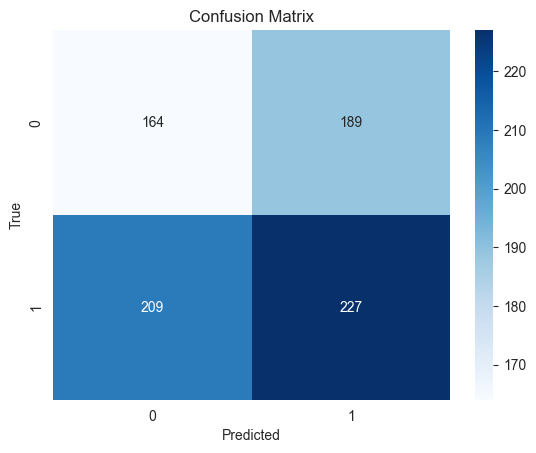

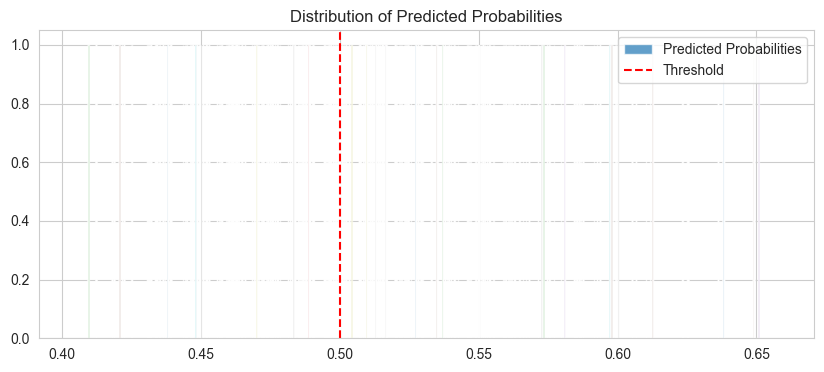

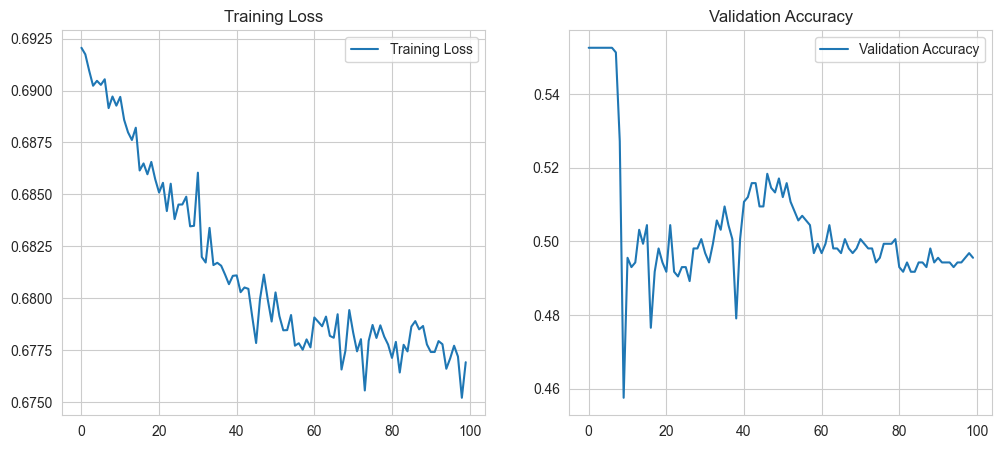

In [51]:
# 6. Evaluate Model
model.eval()
y_pred_list = []
y_true_list = []
y_prob_list = []

with torch.no_grad():
    for inputs_batch, labels_batch in test_loader:
        inputs_batch = inputs_batch.to(device)
        labels_batch = labels_batch.to(device)
        
        outputs = model(inputs_batch)
        probs = torch.sigmoid(outputs)
        predicted = (probs > 0.5).float()
        
        y_pred_list.extend(predicted.cpu().numpy())
        y_true_list.extend(labels_batch.cpu().numpy())
        y_prob_list.extend(probs.cpu().numpy())

y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Plot probabilities distribution
plt.figure(figsize=(10, 4))
plt.hist(y_prob_list, bins=20, alpha=0.7, label='Predicted Probabilities')
plt.axvline(0.5, color='r', linestyle='--', label='Threshold')
plt.title('Distribution of Predicted Probabilities')
plt.legend()
plt.show()

# Plot Loss/Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.show()